In [2]:
import numpy as np
import pandas as pd
import re
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from src import calculate_metrics

In [3]:
df_train = pd.read_csv('../data/train/transformed_train.csv')
X_train = df_train.drop(columns=["Precio"])
y_train = df_train["Precio"]

df_val = pd.read_csv('../data/train/transformed_val.csv')
X_val = df_val.drop(columns=["Precio"])
y_val = df_val["Precio"]

In [4]:
params = {
    "subsample": 1.0,
    "reg_lambda": 1,
    "reg_alpha": 0.01,
    "n_estimators": 600,
    "max_depth": 6,
    "learning_rate": 0.1,
    "gamma": 0,
    "colsample_bytree": 0.6,
    "random_state": 42,
}

model = XGBRegressor(**params)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)

metrics = calculate_metrics(y_train, y_pred_train, y_val, y_pred_val)

Metric       |    Train     |  Validation
-------------|--------------|---------------
MSE          |   3.32e+12   |   4.01e+13
R²           |   0.9959     |   0.9451
MAE          |   1.22e+06   |   3.02e+06
EVS          |   0.9959     |   0.9452
Max Error    |   4.48e+07   |   1.33e+08
Median AE    |   8.40e+05   |   1.56e+06



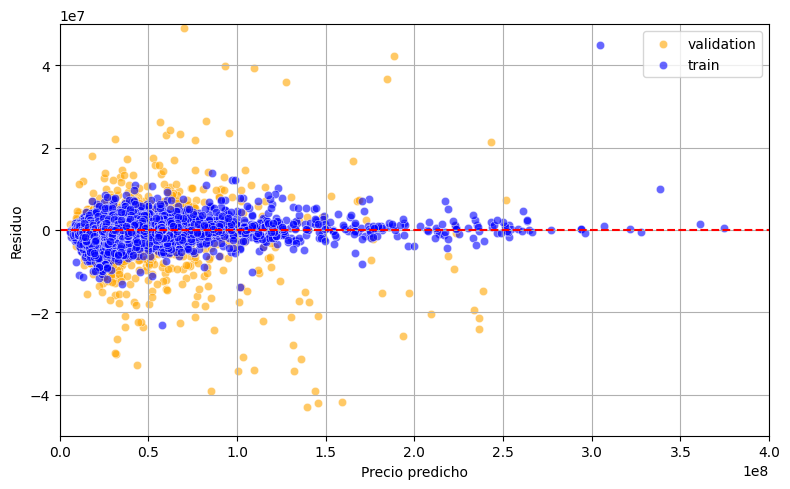

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_val, y=y_val-y_pred_val, alpha=0.6, color='orange', label='validation')
sns.scatterplot(x=y_pred_train, y=y_train - y_pred_train, alpha=0.6, color='blue', label='train')
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Precio predicho")
plt.ylabel("Residuo")
plt.legend()
plt.xlim(0, 4e8)
plt.ylim(-0.5e8, 0.5e8)
plt.grid(True)
plt.tight_layout()
plt.show()

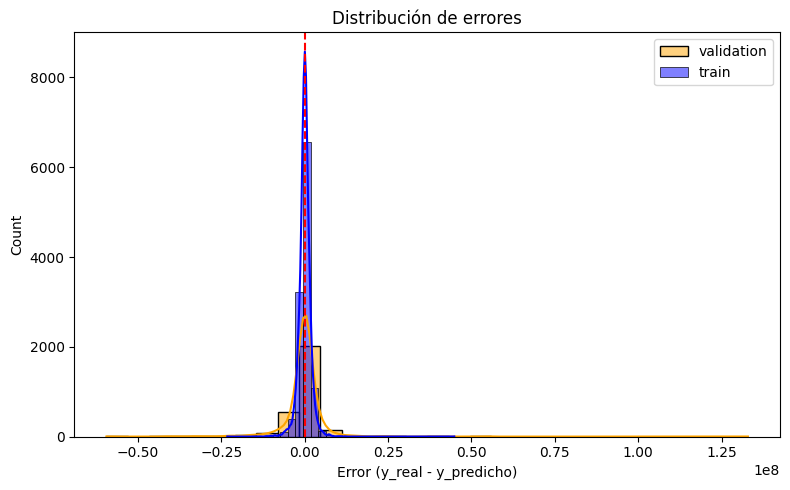

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(y_val-y_pred_val, kde=True, bins=30, color="orange", alpha=0.5, label='validation')
sns.histplot(y_train - y_pred_train, kde=True, bins=30, color="blue", alpha=0.5, label='train')
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Error (y_real - y_predicho)")
plt.title("Distribución de errores")
plt.tight_layout()
plt.legend()
plt.show()

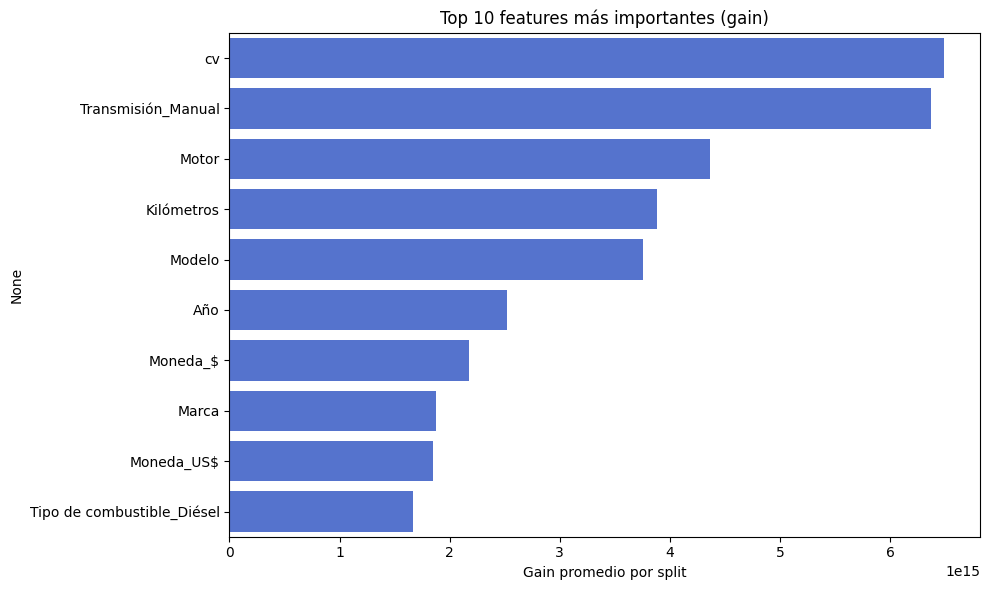

In [7]:
booster = model.get_booster()
fmap = booster.get_score(importance_type='gain')
all_features = {f: fmap.get(f, 0.0) for f in booster.feature_names}
feat_importance = pd.Series(all_features).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importance.values, y=feat_importance.index, color='royalblue')
plt.title("Top 10 features más importantes (gain)")
plt.xlabel("Gain promedio por split")
plt.tight_layout()
plt.show()


In [8]:
df_raw = pd.read_csv('../data/train/cleaned_train.csv')

df_validation = df_val.copy()
df_validation['Predicted'] = y_pred_val
df_validation['abs_error'] = (df_validation['Precio'] - df_validation['Predicted']).abs()
df_validation_sorted = df_validation.sort_values(by='abs_error', ascending=False)

top_n = 10
top_indices = df_validation_sorted.head(top_n)['idx'].values  
df_raw_top_errors = df_raw[df_raw['idx'].isin(top_indices)]

print(f"Top {top_n} peores predicciones - datos originales sin procesar:")
display(df_raw_top_errors)

Top 10 peores predicciones - datos originales sin procesar:


,idx,Marca,Modelo,Año,Versión,Color,Tipo de combustible,Puertas,Transmisión,Motor,Tipo de carrocería,Con cámara de retroceso,Kilómetros,Título,Precio,Moneda,Descripción,Tipo de vendedor,Turbo,cv,Tracción,price_is_anticipo
592,3903,Porsche,Cayenne,2019.0,v6,Gris,Nafta,5.0,Automática,3.6,SUV,0,49000.0,Porsche Cayenne 3.6 V6 300cv,132000.0,US$,"UNICA MANO,Opcionales,Techo panoramico, llanta...",concesionaria,0,300.0,NaN,0
2766,7142,Mercedes-Benz,Clase GLE,2017.0,gle400 sport 4matic,Gris,Nafta,5.0,Automática,3.0,SUV,0,57000.0,Mercedes-Benz Clase GLE 3.0 Gle400 Sport 4mati...,69000.0,US$,"* Service al día, impecable estado * Se puede ...",particular,0,333.0,NaN,0
5723,3370,Mercedes-Benz,Clase GLE,2024.0,gle450 4matic,NaN,Híbrido/Nafta,5.0,Automática,3.0,SUV,0,0.0,Mercedes-Benz Clase GLE 3.0 Gle450 4Matic 381Cv,220000.0,US$,"El Mercedes-Benz GLE combina rendimiento, sost...",concesionaria,0,381.0,NaN,0
6717,9179,Jeep,Wrangler,2013.0,unlimited atx,NaN,Nafta,3.0,Automática,3.6,SUV,0,71000.0,Jeep Wrangler 3.6 Unlimited 284hp Atx,85000.0,US$,"Jeep Wrangler, Automático/Secuencial, Unlimite...",concesionaria,0,284.0,NaN,0
6978,8949,Audi,Q8,2021.0,55 quattro,Gris oscuro,Nafta,5.0,Automática,3.0,SUV,0,44000.0,Audi Q8 3.0 55 Tfsi Quattro,165000.0,US$,Autos Pilar Premium te ofrece un amplio stock ...,concesionaria,1,NaN,NaN,0
8034,798,BMW,X5,2016.0,xdrive 50i m package,Azul,Nafta,5.0,Automática,4.4,SUV,0,51000.0,BMW X5 4.4 Xdrive 50i 449cv M Package,74000.0,US$,SEGUNDO DUEÑO – SERVICES OFICIALESALFOMBRAS RI...,tienda,0,449.0,NaN,0
9734,6336,Porsche,Cayenne,2022.0,(e3) - argentina,Gris,Nafta,5.0,Automática,4.0,SUV,Sí,14000.0,Porsche Cayenne Turbo (e3) - Porsche Argentina,345000.0,US$,En Nordenwagen S.A. somos el único importador ...,tienda,1,550.0,NaN,0
10907,492,Mercedes-Benz,Clase GLE,2018.0,gle400 sport 4matic,Gris,Nafta,5.0,Automática,3.0,SUV,0,64800.0,Mercedes-Benz Clase GLE 3.0 Gle400 Sport 4mati...,59000.0,US$,Mercedes Benz Gle 400 4matic 2018 Cubiertas ya...,concesionaria,0,333.0,NaN,0
11212,3167,BMW,X3,2021.0,m,Azul,Nafta,5.0,Automática,2.0,SUV,0,31000.0,BMW X3 M,139000.0,US$,"X3 M 480 CV estado inmaculado, sin detalles",particular,0,480.0,NaN,0
12768,11234,Volkswagen,Nivus,2025.0,200 comfortline,Gris,Nafta,5.0,Automática,1.0,SUV,Sí,0.0,Volkswagen Nivus 1.0 Tsi 200 Comfortline,32500000.0,$,** VOLKSWAGEN MAYNAR AG. ** 50 AÑOS ** EN EL M...,tienda,1,NaN,NaN,0


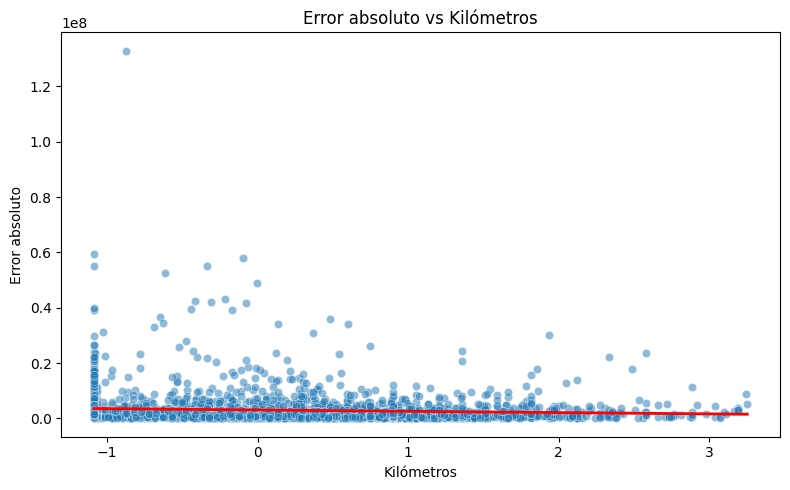

Top 10 marcas con mayor MAE (según Marca original de df_raw):
            Marca           MAE
0         Porsche  3.064335e+07
1           Haval  2.040712e+07
2  DS AUTOMOBILES  1.371172e+07
3   Mercedes-Benz  1.352224e+07
4             D·S  1.284583e+07
5      Land Rover  9.941486e+06
6      Mitsubishi  9.828628e+06
7           Lexus  9.295276e+06
8           Jetur  8.829940e+06
9           Isuzu  8.416863e+06


In [9]:
df = df_validation.merge(df_raw[['idx', 'Marca']], on='idx', how='left', suffixes=('', '_raw'))

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Kilómetros', y='abs_error', alpha=0.5)
sns.regplot(data=df, x='Kilómetros', y='abs_error', scatter=False, color='red', line_kws={'linewidth':2})
plt.xlabel('Kilómetros')
plt.ylabel('Error absoluto')
plt.title('Error absoluto vs Kilómetros')
plt.tight_layout()
plt.show()

rmse_por_marca = df.groupby('Marca_raw')['abs_error'].mean().sort_values(ascending=False)
top10_rmse = rmse_por_marca.head(10).reset_index()
top10_rmse.columns = ['Marca', 'MAE']

print("Top 10 marcas con mayor MAE (según Marca original de df_raw):")
print(top10_rmse)

In [10]:
grouped = df.groupby('Marca').agg(
    MAE = ('abs_error', lambda x: np.sqrt(np.mean(x))),
    Count = ('Marca_raw', 'count')
)

top_most_data = grouped.sort_values(by='Count', ascending=False).head(10).reset_index()

print("Top 10 marcas con más cantidad de datos y su RMSE:")
print(top_most_data)


Top 10 marcas con más cantidad de datos y su RMSE:
          Marca          MAE  Count
0  2.364476e+07  1837.235586    347
1  1.571700e+07  1176.609211    329
2  2.824417e+07  1638.494187    299
3  2.195435e+07  1417.556059    270
4  1.530751e+07  1293.126518    241
5  2.036304e+07  1629.973286    210
6  2.246936e+07  1914.295348    197
7  2.136067e+07  1185.811662    161
8  2.053501e+07  1349.427412    123
9  7.183297e+06  1429.676805     99
